# Priorização de Hipóteses e Teste A/B

Este projeto faz parte do curso "Tomando Decisões de Negócios Baseados em Dados".  
O objetivo é:

1. Priorizar hipóteses de marketing usando os frameworks **ICE** e **RICE**.
2. Analisar os resultados de um **teste A/B** para entender o impacto em receita, conversão e ticket médio.


## Estrutura do projeto

- **Parte 1 – Priorizando hipóteses**
  - Importação e visualização dos dados
  - Cálculo do score ICE
  - Cálculo do score RICE
  - Comparação entre ICE e RICE e conclusões

- **Parte 2 – Análise do teste A/B**
  - Preparação e limpeza dos dados
  - Análise de receita e tamanho médio dos pedidos
  - Análise de conversão
  - Detecção de anomalias (outliers)
  - Testes de significância estatística
  - Conclusões e decisão final sobre o teste


In [1]:
import pandas as pd

pd.__version__

'1.2.4'

In [2]:
# Carregando o dataset de hipóteses
hypotheses = pd.read_csv('/datasets/hypotheses_us.csv')

# Vendo as primeiras linhas
hypotheses.head()


,Hypothesis;Reach;Impact;Confidence;Effort
0,Add two new channels for attracting traffic. T...
1,Launch your own delivery service. This will sh...
2,Add product recommendation blocks to the store...
3,Change the category structure. This will incre...
4,Change the background color on the main page. ...


In [3]:
hypotheses.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 1 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Hypothesis;Reach;Impact;Confidence;Effort  9 non-null      object
dtypes: object(1)
memory usage: 200.0+ bytes


## Parte 1 – Priorizando hipóteses

### 1. Importação dos dados de hipóteses

Nesta etapa, importei o arquivo `hypotheses_us.csv`, que contém a lista de hipóteses de marketing para aumentar a receita da loja online.

Cada linha representa uma hipótese e contém as seguintes colunas:

- **Hypothesis** – descrição curta da hipótese
- **Reach** – alcance de usuários (1 a 10)
- **Impact** – impacto esperado nos usuários (1 a 10)
- **Confidence** – quão confiantes estamos na hipótese (1 a 10)
- **Effort** – esforço necessário para implementar o teste (1 a 10)

Essas variáveis serão usadas para calcular os scores **ICE** e **RICE**, que nos ajudam a definir quais hipóteses devem ser priorizadas.


In [4]:
hypotheses.columns


Index(['Hypothesis;Reach;Impact;Confidence;Effort'], dtype='object')

In [5]:
import pandas as pd

# Carregando o dataset de hipóteses com separador ';'
hypotheses = pd.read_csv('/datasets/hypotheses_us.csv', sep=';')

hypotheses.head()


,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1


### Ajuste na importação dos dados

Ao verificar os nomes das colunas, notei que o arquivo `hypotheses_us.csv` havia sido lido com todas as colunas juntas em uma única string (`'Hypothesis;Reach;Impact;Confidence;Effort'`).

Isso acontece porque o arquivo usa **ponto e vírgula (`;`) como separador**, e não vírgula.

Para corrigir isso, recarreguei o arquivo usando o parâmetro `sep=';'` na função `read_csv`.  
Depois disso, as colunas passaram a ser reconhecidas corretamente como:

- `Hypothesis`
- `Reach`
- `Impact`
- `Confidence`
- `Effort`


### Calculo de ICE ###

In [6]:
# Calculando o score ICE para cada hipótese
hypotheses['ICE'] = (
    hypotheses['Impact'] * hypotheses['Confidence'] / hypotheses['Effort']
)

# Visualizando as primeiras linhas com o ICE
hypotheses[['Hypothesis', 'ICE']].head()


,Hypothesis,ICE
0,Add two new channels for attracting traffic. T...,13.333333
1,Launch your own delivery service. This will sh...,2.000000
2,Add product recommendation blocks to the store...,7.000000
3,Change the category structure. This will incre...,1.125000
4,Change the background color on the main page. ...,1.000000


In [7]:
hypotheses_ice = hypotheses[['Hypothesis', 'ICE']].sort_values(
    by='ICE',
    ascending=False
)

hypotheses_ice


,Hypothesis,ICE
8,Launch a promotion that gives users discounts ...,16.200000
0,Add two new channels for attracting traffic. T...,13.333333
7,Add a subscription form to all the main pages....,11.200000
6,Show banners with current offers and sales on ...,8.000000
2,Add product recommendation blocks to the store...,7.000000
1,Launch your own delivery service. This will sh...,2.000000
5,Add a customer review page. This will increase...,1.333333
3,Change the category structure. This will incre...,1.125000
4,Change the background color on the main page. ...,1.000000


### Análise dos resultados do ICE

De acordo com o framework ICE, a hipótese com maior prioridade é **"Launch a promotion that gives users discounts"**, que obteve o maior score ICE.

Isso indica que essa hipótese combina:
- alto impacto esperado,
- alta confiança na sua eficácia,
- e esforço relativamente baixo para implementação.

Outras hipóteses bem posicionadas no ranking, como **"Add two new channels for attracting traffic"** e **"Add a subscription form to all the main pages"**, também apresentam uma boa relação entre impacto, confiança e esforço.

Por outro lado, hipóteses como **"Change the background color on the main page"** e **"Change the category structure"** ficaram nas últimas posições, principalmente devido ao baixo impacto esperado ou alto esforço em relação aos benefícios estimados.


### Framework RICE ###

### Priorização das hipóteses usando o framework RICE

Após a análise das hipóteses utilizando o framework ICE, aplicamos o framework **RICE**, que adiciona o fator **Reach** (alcance) ao cálculo.

O objetivo do RICE é priorizar hipóteses que não apenas tenham alto impacto e confiança, mas que também afetem um **grande número de usuários**.


### Cálculo de RICE ###

In [8]:
# Calculando o score RICE para cada hipótese
hypotheses['RICE'] = (
    hypotheses['Reach'] *
    hypotheses['Impact'] *
    hypotheses['Confidence'] /
    hypotheses['Effort']
)

# Visualizando as primeiras linhas com o RICE
hypotheses[['Hypothesis', 'RICE']].head()


,Hypothesis,RICE
0,Add two new channels for attracting traffic. T...,40.0
1,Launch your own delivery service. This will sh...,4.0
2,Add product recommendation blocks to the store...,56.0
3,Change the category structure. This will incre...,9.0
4,Change the background color on the main page. ...,3.0


In [9]:
hypotheses_rice = hypotheses[['Hypothesis', 'RICE']].sort_values(
    by='RICE',
    ascending=False
)

hypotheses_rice


,Hypothesis,RICE
7,Add a subscription form to all the main pages....,112.0
2,Add product recommendation blocks to the store...,56.0
0,Add two new channels for attracting traffic. T...,40.0
6,Show banners with current offers and sales on ...,40.0
8,Launch a promotion that gives users discounts ...,16.2
3,Change the category structure. This will incre...,9.0
1,Launch your own delivery service. This will sh...,4.0
5,Add a customer review page. This will increase...,4.0
4,Change the background color on the main page. ...,3.0


### COMPARAÇÃO ICE × RICE ###

In [10]:
comparison = hypotheses[['Hypothesis', 'ICE', 'RICE']].copy()

comparison = comparison.sort_values(by='RICE', ascending=False)

comparison


,Hypothesis,ICE,RICE
7,Add a subscription form to all the main pages....,11.200000,112.0
2,Add product recommendation blocks to the store...,7.000000,56.0
0,Add two new channels for attracting traffic. T...,13.333333,40.0
6,Show banners with current offers and sales on ...,8.000000,40.0
8,Launch a promotion that gives users discounts ...,16.200000,16.2
3,Change the category structure. This will incre...,1.125000,9.0
1,Launch your own delivery service. This will sh...,2.000000,4.0
5,Add a customer review page. This will increase...,1.333333,4.0
4,Change the background color on the main page. ...,1.000000,3.0


### Comparação entre ICE e RICE

Ao comparar os rankings obtidos pelos frameworks ICE e RICE, é possível observar mudanças significativas na priorização das hipóteses.

No ranking ICE, a hipótese **"Launch a promotion that gives users discounts"** obteve a maior prioridade, pois apresenta alto impacto e confiança com esforço relativamente baixo.

Entretanto, ao aplicar o framework RICE, a hipótese **"Add a subscription form to all the main pages"** passou a ocupar a primeira posição. Isso ocorre porque o RICE considera o fator **Reach**, ou seja, o número de usuários impactados pela hipótese.

Hipóteses que afetam um grande volume de usuários tendem a subir no ranking RICE, mesmo que não tenham o maior score ICE. Por outro lado, hipóteses com alto impacto, mas alcance limitado, podem perder prioridade quando o alcance é considerado.

Dessa forma, o framework RICE permite uma visão mais ampla, priorizando hipóteses que podem gerar maior impacto em escala.


### Conclusão da Parte 1

Com base nos resultados, o framework ICE é útil para identificar hipóteses com boa relação entre impacto, confiança e esforço.

No entanto, o framework RICE adiciona uma camada importante de análise ao considerar o alcance da hipótese. Por isso, ele é mais adequado quando o objetivo é maximizar o impacto em um grande número de usuários.

Dessa forma, para este projeto, as hipóteses priorizadas pelo RICE fornecem uma base mais robusta para a tomada de decisão sobre quais testes devem ser realizados primeiro.


## Parte 2 – Análise do Teste A/B

Nesta etapa do projeto, analisamos os resultados de um teste A/B realizado em uma loja online.

O objetivo é comparar o desempenho dos grupos **A** e **B** em termos de:
- receita,
- tamanho médio dos pedidos,
- taxa de conversão,

e tomar uma decisão baseada em evidências estatísticas.


### Importação das bibliotecas

Para a análise do teste A/B, utilizaremos bibliotecas para manipulação de dados, visualização e testes estatísticos.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest


In [12]:
# Carregando os dados de pedidos
orders = pd.read_csv('/datasets/orders_us.csv')

# Carregando os dados de visitas
visits = pd.read_csv('/datasets/visits_us.csv')

orders.head(), visits.head()


(   transactionId   visitorId        date  revenue group
 0     3667963787  3312258926  2019-08-15     30.4     B
 1     2804400009  3642806036  2019-08-15     15.2     B
 2     2961555356  4069496402  2019-08-15     10.2     A
 3     3797467345  1196621759  2019-08-15    155.1     B
 4     2282983706  2322279887  2019-08-15     40.5     B,
          date group  visits
 0  2019-08-01     A     719
 1  2019-08-02     A     619
 2  2019-08-03     A     507
 3  2019-08-04     A     717
 4  2019-08-05     A     756)

### Descrição dos dados

O arquivo `orders_us.csv` contém informações sobre os pedidos realizados durante o teste A/B, incluindo:
- `transactionId` — identificador do pedido,
- `visitorId` — identificador do usuário,
- `date` — data do pedido,
- `revenue` — valor do pedido,
- `group` — grupo do teste A/B (A ou B).

O arquivo `visits_us.csv` contém informações sobre o número de visitas diárias para cada grupo:
- `date` — data,
- `group` — grupo do teste A/B,
- `visits` — número de visitas no dia.


In [13]:
# Convertendo as colunas de data para o formato datetime
orders['date'] = pd.to_datetime(orders['date'])
visits['date'] = pd.to_datetime(visits['date'])

orders.info()
visits.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1197 non-null   int64         
 1   visitorId      1197 non-null   int64         
 2   date           1197 non-null   datetime64[ns]
 3   revenue        1197 non-null   float64       
 4   group          1197 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 46.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    62 non-null     datetime64[ns]
 1   group   62 non-null     object        
 2   visits  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB


### VERIFICANDO OS GRUPOS A/B ###

In [14]:
orders['group'].value_counts()


B    640
A    557
Name: group, dtype: int64

In [15]:
visits['group'].value_counts()


A    31
B    31
Name: group, dtype: int64

### Distribuição dos grupos A/B

Antes de iniciar a análise, verifiquei a distribuição dos dados entre os grupos A e B tanto nos pedidos quanto nas visitas.

Essa verificação garante que ambos os grupos estão presentes nos dados e que o teste A/B foi registrado corretamente.


### VERIFICANDO USUÁRIOS EM MAIS DE UM GRUPO ###

In [16]:
users_groups = (
    orders
    .groupby('visitorId')['group']
    .nunique()
    .reset_index()
)

users_groups[users_groups['group'] > 1]


,visitorId,group
2,8300375,2
44,199603092,2
51,232979603,2
55,237748145,2
66,276558944,2
84,351125977,2
97,393266494,2
114,457167155,2
119,471551937,2
122,477780734,2


### REMOÇÃO DE USUÁRIOS EM MÚLTIPLOS GRUPOS ###

In [17]:
# Criando a lista de usuários que aparecem em mais de um grupo
users_to_remove = users_groups[users_groups['group'] > 1]['visitorId']

users_to_remove.head()


2       8300375
44    199603092
51    232979603
55    237748145
66    276558944
Name: visitorId, dtype: int64

In [18]:
# Removendo usuários que participaram de mais de um grupo
orders_clean = orders[~orders['visitorId'].isin(users_to_remove)]

orders_clean.head()


,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B
5,182168103,935554773,2019-08-15,35.0,B


In [19]:
# Verificando novamente se ainda existem usuários em mais de um grupo
users_groups_clean = (
    orders_clean
    .groupby('visitorId')['group']
    .nunique()
    .reset_index()
)

users_groups_clean[users_groups_clean['group'] > 1]


,visitorId,group


### Remoção de usuários em múltiplos grupos

Durante a análise, foi identificado que alguns usuários apareceram em mais de um grupo do teste A/B.

Esse comportamento pode enviesar os resultados, pois um mesmo usuário foi exposto a diferentes variações do teste.

Para garantir a independência das amostras e a validade da análise estatística, esses usuários foram removidos de ambos os grupos antes de prosseguir com a análise.


### Receita acumulada por grupo

Para analisar o desempenho financeiro do teste A/B, começamos avaliando a **receita acumulada** de cada grupo ao longo do tempo.

A receita acumulada permite observar tendências, diferenças entre os grupos e possíveis efeitos do teste conforme os dias passam.


In [20]:
# Calculando a receita diária por grupo
revenue_by_date = (
    orders_clean
    .groupby(['date', 'group'])['revenue']
    .sum()
    .reset_index()
)

revenue_by_date.head()


,date,group,revenue
0,2019-08-01,A,2266.6
1,2019-08-01,B,967.2
2,2019-08-02,A,1468.3
3,2019-08-02,B,2568.1
4,2019-08-03,A,1815.2


In [21]:
# Ordenando os dados
revenue_by_date = revenue_by_date.sort_values(by=['group', 'date'])

# Calculando a receita acumulada
revenue_by_date['cumulative_revenue'] = (
    revenue_by_date
    .groupby('group')['revenue']
    .cumsum()
)

revenue_by_date.head()


,date,group,revenue,cumulative_revenue
0,2019-08-01,A,2266.6,2266.6
2,2019-08-02,A,1468.3,3734.9
4,2019-08-03,A,1815.2,5550.1
6,2019-08-04,A,675.5,6225.6
8,2019-08-05,A,1398.0,7623.6


### Gráfico da Receita Acumulada ###

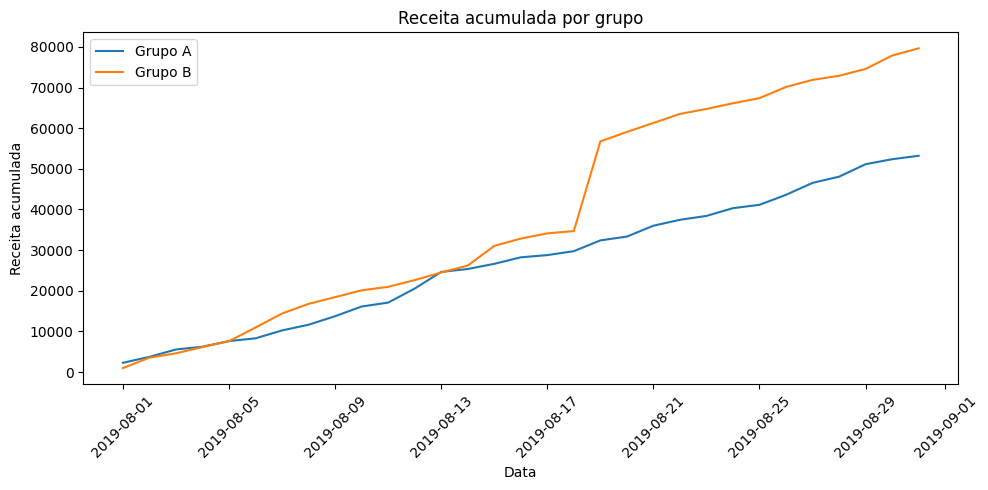

In [22]:
plt.figure(figsize=(10, 5))

for group in revenue_by_date['group'].unique():
    data = revenue_by_date[revenue_by_date['group'] == group]
    plt.plot(
        data['date'],
        data['cumulative_revenue'],
        label=f'Grupo {group}'
    )

plt.xlabel('Data')
plt.ylabel('Receita acumulada')
plt.title('Receita acumulada por grupo')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### Análise da receita acumulada

O gráfico da receita acumulada mostra que o **grupo B** apresenta uma receita maior do que o grupo A durante a maior parte do período do teste.

Observa-se um **salto significativo** na receita acumulada do grupo B por volta da metade do experimento, o que pode indicar a presença de pedidos de valor atípico (outliers).

Enquanto isso, a receita acumulada do grupo A cresce de forma mais estável e gradual ao longo do tempo.

Apesar de o grupo B aparentar melhor desempenho em termos de receita, a presença de possíveis outliers indica que é necessário analisar outras métricas e aplicar testes estatísticos antes de tomar uma decisão final.



### TAMANHO MÉDIO ACUMULADO DO PEDIDO (AOV) ###

### Tamanho médio acumulado do pedido

Em seguida, analisamos o **tamanho médio acumulado do pedido** (Average Order Value – AOV).

Essa métrica permite entender se a diferença de receita entre os grupos é causada por:
- mais pedidos,
- pedidos de maior valor,
- ou pela presença de pedidos atípicos.


In [23]:
# Calculando o número de pedidos diários por grupo
orders_by_date = (
    orders_clean
    .groupby(['date', 'group'])['transactionId']
    .nunique()
    .reset_index()
    .rename(columns={'transactionId': 'orders'})
)

orders_by_date.head()


,date,group,orders
0,2019-08-01,A,23
1,2019-08-01,B,17
2,2019-08-02,A,19
3,2019-08-02,B,23
4,2019-08-03,A,24


In [24]:
# Unindo receita e pedidos em um único DataFrame
daily_metrics = revenue_by_date.merge(
    orders_by_date,
    on=['date', 'group'],
    how='left'
)

daily_metrics.head()


,date,group,revenue,cumulative_revenue,orders
0,2019-08-01,A,2266.6,2266.6,23
1,2019-08-02,A,1468.3,3734.9,19
2,2019-08-03,A,1815.2,5550.1,24
3,2019-08-04,A,675.5,6225.6,11
4,2019-08-05,A,1398.0,7623.6,22


In [25]:
# Calculando métricas acumuladas
daily_metrics = daily_metrics.sort_values(by=['group', 'date'])

daily_metrics['cumulative_orders'] = (
    daily_metrics
    .groupby('group')['orders']
    .cumsum()
)

daily_metrics['cumulative_avg_order'] = (
    daily_metrics['cumulative_revenue'] /
    daily_metrics['cumulative_orders']
)

daily_metrics.head()


,date,group,revenue,cumulative_revenue,orders,cumulative_orders,cumulative_avg_order
0,2019-08-01,A,2266.6,2266.6,23,23,98.547826
1,2019-08-02,A,1468.3,3734.9,19,42,88.926190
2,2019-08-03,A,1815.2,5550.1,24,66,84.092424
3,2019-08-04,A,675.5,6225.6,11,77,80.851948
4,2019-08-05,A,1398.0,7623.6,22,99,77.006061


### Gráfico do AOV acumulado ###

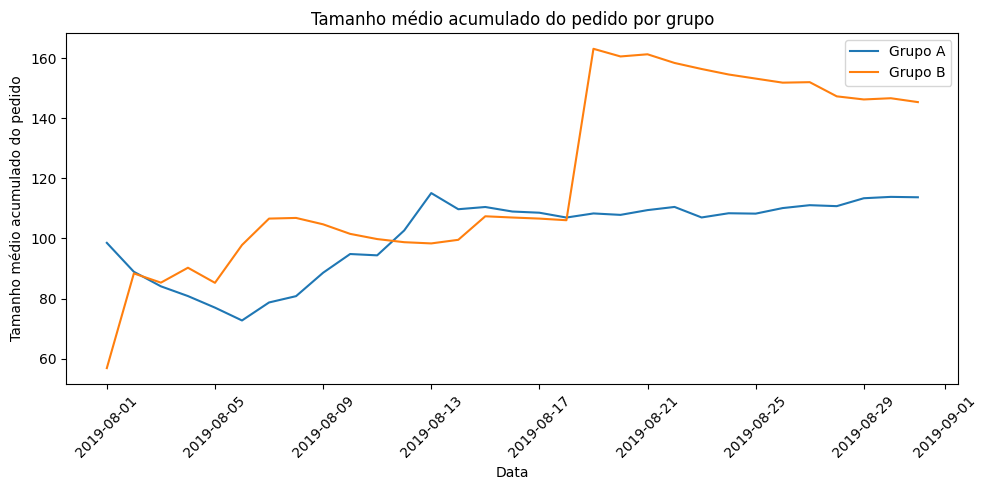

In [26]:
plt.figure(figsize=(10, 5))

for group in daily_metrics['group'].unique():
    data = daily_metrics[daily_metrics['group'] == group]
    plt.plot(
        data['date'],
        data['cumulative_avg_order'],
        label=f'Grupo {group}'
    )

plt.xlabel('Data')
plt.ylabel('Tamanho médio acumulado do pedido')
plt.title('Tamanho médio acumulado do pedido por grupo')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Análise do tamanho médio acumulado do pedido

O gráfico do tamanho médio acumulado do pedido mostra que o grupo B apresenta valores mais elevados em comparação ao grupo A durante a maior parte do experimento.

Observa-se um salto acentuado no AOV do grupo B por volta da metade do período analisado, o que indica a presença de pedidos de valor atípico (outliers).

Após esse salto, o AOV do grupo B se mantém em um nível superior ao do grupo A, enquanto o grupo A apresenta um crescimento mais estável e gradual ao longo do tempo.

Esses resultados sugerem que a maior receita observada no grupo B pode estar relacionada a pedidos de alto valor, e não necessariamente a um aumento consistente no comportamento médio dos usuários.


### DIFERENÇA RELATIVA DO AOV (B VS A) ##

In [27]:
# Criando uma tabela pivot com o AOV acumulado por grupo
aov_pivot = daily_metrics.pivot_table(
    index='date',
    columns='group',
    values='cumulative_avg_order'
)

aov_pivot.head()


group,A,B
date,,
2019-08-01,98.547826,56.894118
2019-08-02,88.926190,88.382500
2019-08-03,84.092424,85.312963
2019-08-04,80.851948,90.272059
2019-08-05,77.006061,85.256180


In [28]:
# Calculando a diferença relativa do AOV entre os grupos
aov_pivot['relative_diff'] = (
    (aov_pivot['B'] - aov_pivot['A']) / aov_pivot['A']
)

aov_pivot.head()


group,A,B,relative_diff
date,,,
2019-08-01,98.547826,56.894118,-0.422675
2019-08-02,88.926190,88.382500,-0.006114
2019-08-03,84.092424,85.312963,0.014514
2019-08-04,80.851948,90.272059,0.116511
2019-08-05,77.006061,85.256180,0.107136


### Gráfico da diferença relativa do AOV ###

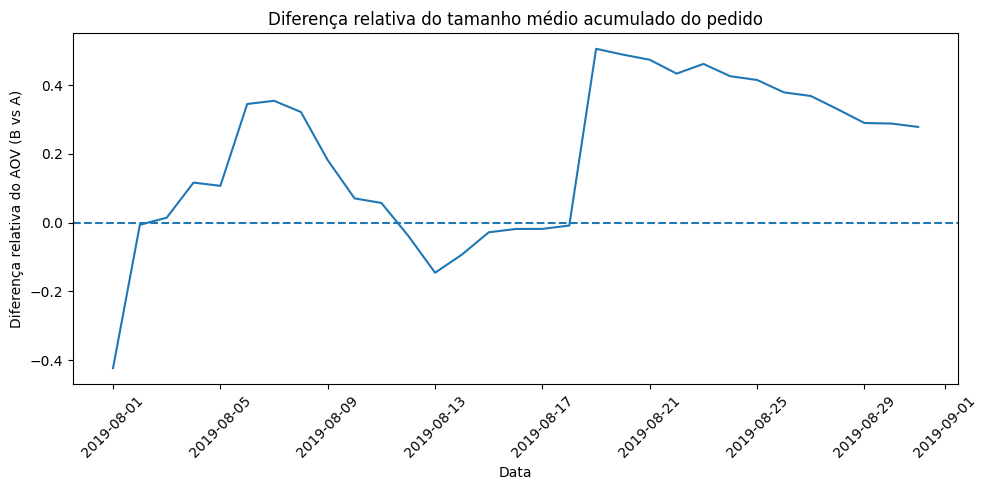

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(
    aov_pivot.index,
    aov_pivot['relative_diff']
)

plt.axhline(y=0, linestyle='--')

plt.xlabel('Data')
plt.ylabel('Diferença relativa do AOV (B vs A)')
plt.title('Diferença relativa do tamanho médio acumulado do pedido')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Análise da diferença relativa do tamanho médio acumulado do pedido

O gráfico da diferença relativa do tamanho médio acumulado do pedido mostra como o AOV do grupo B se comporta em relação ao grupo A ao longo do tempo.

No início do experimento, observa-se grande variação na diferença relativa, o que é esperado devido ao baixo número de pedidos e à instabilidade da média.

Por volta da metade do período analisado, ocorre um salto significativo na diferença relativa, indicando que o AOV do grupo B se tornou substancialmente maior que o do grupo A. Esse comportamento está associado à presença de pedidos de alto valor no grupo B.

Após esse pico, a diferença relativa permanece positiva, mas apresenta uma tendência de redução gradual, sugerindo que o efeito dos pedidos atípicos vai sendo diluído ao longo do tempo.

Esses resultados reforçam a necessidade de analisar a presença de outliers e complementar a análise com testes estatísticos antes de tomar uma decisão final sobre o teste A/B.


### Taxa de conversão diária

A taxa de conversão é calculada como a proporção entre o número de pedidos e o número de visitas.

Essa métrica permite avaliar se um grupo converte melhor que o outro, independentemente do valor dos pedidos.


In [30]:
# Calculando o número de pedidos diários por grupo
daily_orders = (
    orders_clean
    .groupby(['date', 'group'])['transactionId']
    .nunique()
    .reset_index()
    .rename(columns={'transactionId': 'orders'})
)

daily_orders.head()


,date,group,orders
0,2019-08-01,A,23
1,2019-08-01,B,17
2,2019-08-02,A,19
3,2019-08-02,B,23
4,2019-08-03,A,24


In [31]:
# Unindo pedidos e visitas
conversion_data = daily_orders.merge(
    visits,
    on=['date', 'group'],
    how='left'
)

conversion_data.head()


,date,group,orders,visits
0,2019-08-01,A,23,719
1,2019-08-01,B,17,713
2,2019-08-02,A,19,619
3,2019-08-02,B,23,581
4,2019-08-03,A,24,507


In [32]:
# Calculando a taxa de conversão diária
conversion_data['conversion_rate'] = (
    conversion_data['orders'] / conversion_data['visits']
)

conversion_data.head()


,date,group,orders,visits,conversion_rate
0,2019-08-01,A,23,719,0.031989
1,2019-08-01,B,17,713,0.023843
2,2019-08-02,A,19,619,0.030695
3,2019-08-02,B,23,581,0.039587
4,2019-08-03,A,24,507,0.047337


### Gráfico da taxa de conversão diária ###

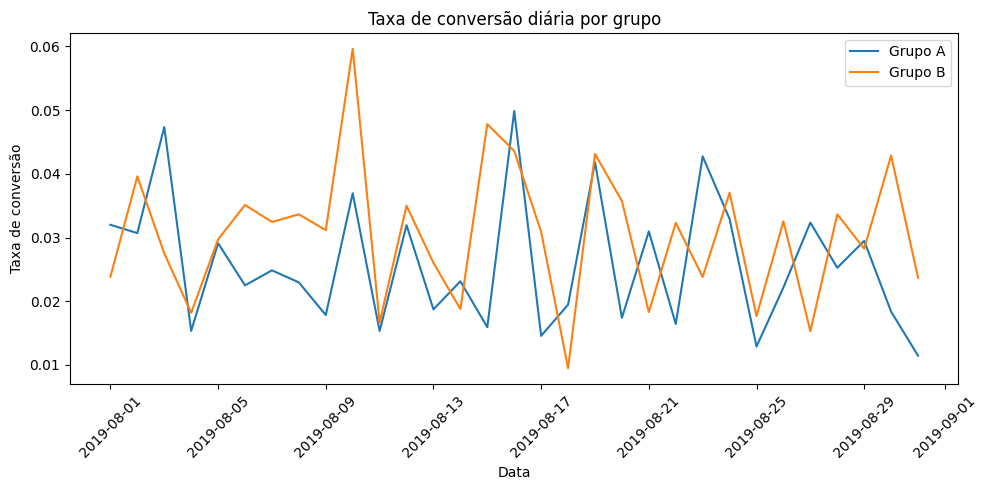

In [33]:
plt.figure(figsize=(10, 5))

for group in conversion_data['group'].unique():
    data = conversion_data[conversion_data['group'] == group]
    plt.plot(
        data['date'],
        data['conversion_rate'],
        label=f'Grupo {group}'
    )

plt.xlabel('Data')
plt.ylabel('Taxa de conversão')
plt.title('Taxa de conversão diária por grupo')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Análise da taxa de conversão diária

O gráfico da taxa de conversão diária mostra que ambos os grupos apresentam variações significativas ao longo do tempo.

Em alguns dias, o grupo A apresenta taxa de conversão superior, enquanto em outros dias o grupo B se destaca. As linhas se cruzam diversas vezes, indicando que não há um vencedor claro na conversão diária apenas pela inspeção visual.

Esse comportamento é esperado em dados diários, uma vez que a taxa de conversão pode variar devido a flutuações naturais no número de visitas e pedidos.

Para uma análise mais robusta, é necessário observar a **conversão acumulada** e aplicar testes estatísticos.


### CONVERSÃO ACUMULADA

In [34]:
# Ordenando os dados
conversion_data = conversion_data.sort_values(by=['group', 'date'])

# Calculando valores acumulados
conversion_data['cumulative_orders'] = (
    conversion_data
    .groupby('group')['orders']
    .cumsum()
)

conversion_data['cumulative_visits'] = (
    conversion_data
    .groupby('group')['visits']
    .cumsum()
)

conversion_data['cumulative_conversion'] = (
    conversion_data['cumulative_orders'] /
    conversion_data['cumulative_visits']
)

conversion_data.head()


,date,group,orders,visits,conversion_rate,cumulative_orders,cumulative_visits,cumulative_conversion
0,2019-08-01,A,23,719,0.031989,23,719,0.031989
2,2019-08-02,A,19,619,0.030695,42,1338,0.031390
4,2019-08-03,A,24,507,0.047337,66,1845,0.035772
6,2019-08-04,A,11,717,0.015342,77,2562,0.030055
8,2019-08-05,A,22,756,0.029101,99,3318,0.029837


### Gráfico da conversão acumulkada

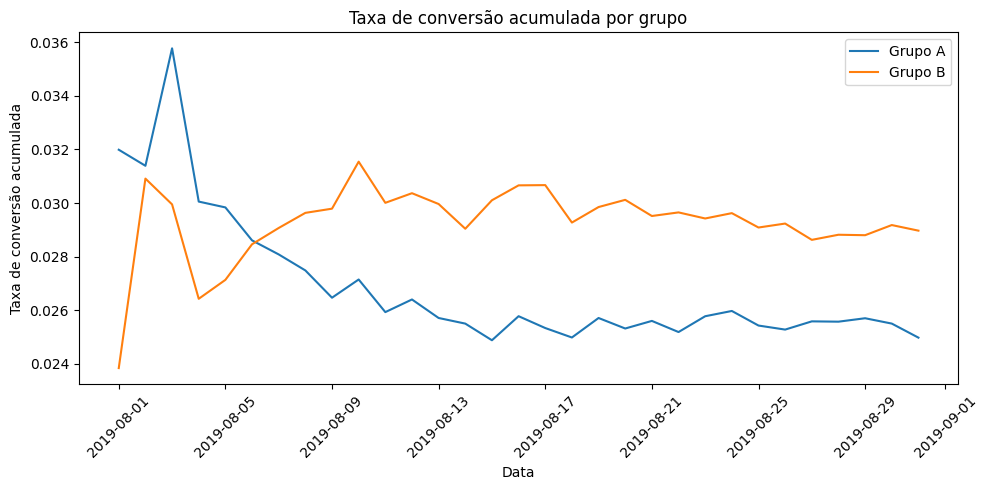

In [35]:
plt.figure(figsize=(10, 5))

for group in conversion_data['group'].unique():
    data = conversion_data[conversion_data['group'] == group]
    plt.plot(
        data['date'],
        data['cumulative_conversion'],
        label=f'Grupo {group}'
    )

plt.xlabel('Data')
plt.ylabel('Taxa de conversão acumulada')
plt.title('Taxa de conversão acumulada por grupo')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Análise da taxa de conversão acumulada

O gráfico da taxa de conversão acumulada mostra a evolução da conversão dos grupos A e B ao longo do tempo.

No início do experimento, observa-se alta variação nas taxas de conversão, o que é esperado devido ao baixo número de observações nos primeiros dias.

Ao longo do período analisado, a taxa de conversão do grupo B ultrapassa a do grupo A e se mantém consistentemente maior até o final do experimento.

Enquanto o grupo A apresenta uma tendência de queda e posterior estabilização em um nível inferior, o grupo B demonstra uma conversão mais estável e superior, sugerindo melhor desempenho em termos de conversão.


### DIFERENÇA RELATIVA DA CONVERSÃO (B VS A)

In [36]:
# Ordenando os dados
conversion_data = conversion_data.sort_values(by=['group', 'date'])

# Calculando métricas acumuladas
conversion_data['cumulative_orders'] = (
    conversion_data
    .groupby('group')['orders']
    .cumsum()
)

conversion_data['cumulative_visits'] = (
    conversion_data
    .groupby('group')['visits']
    .cumsum()
)

conversion_data['cumulative_conversion'] = (
    conversion_data['cumulative_orders'] /
    conversion_data['cumulative_visits']
)

conversion_data.head()


,date,group,orders,visits,conversion_rate,cumulative_orders,cumulative_visits,cumulative_conversion
0,2019-08-01,A,23,719,0.031989,23,719,0.031989
2,2019-08-02,A,19,619,0.030695,42,1338,0.031390
4,2019-08-03,A,24,507,0.047337,66,1845,0.035772
6,2019-08-04,A,11,717,0.015342,77,2562,0.030055
8,2019-08-05,A,22,756,0.029101,99,3318,0.029837


In [37]:
conversion_pivot = conversion_data.pivot_table(
    index='date',
    columns='group',
    values='cumulative_conversion'
)

conversion_pivot.head()


group,A,B
date,,
2019-08-01,0.031989,0.023843
2019-08-02,0.031390,0.030912
2019-08-03,0.035772,0.029950
2019-08-04,0.030055,0.026428
2019-08-05,0.029837,0.027134


In [38]:
conversion_pivot['relative_diff'] = (
    (conversion_pivot['B'] - conversion_pivot['A']) /
    conversion_pivot['A']
)

conversion_pivot.head()


group,A,B,relative_diff
date,,,
2019-08-01,0.031989,0.023843,-0.254650
2019-08-02,0.031390,0.030912,-0.015235
2019-08-03,0.035772,0.029950,-0.162759
2019-08-04,0.030055,0.026428,-0.120659
2019-08-05,0.029837,0.027134,-0.090595


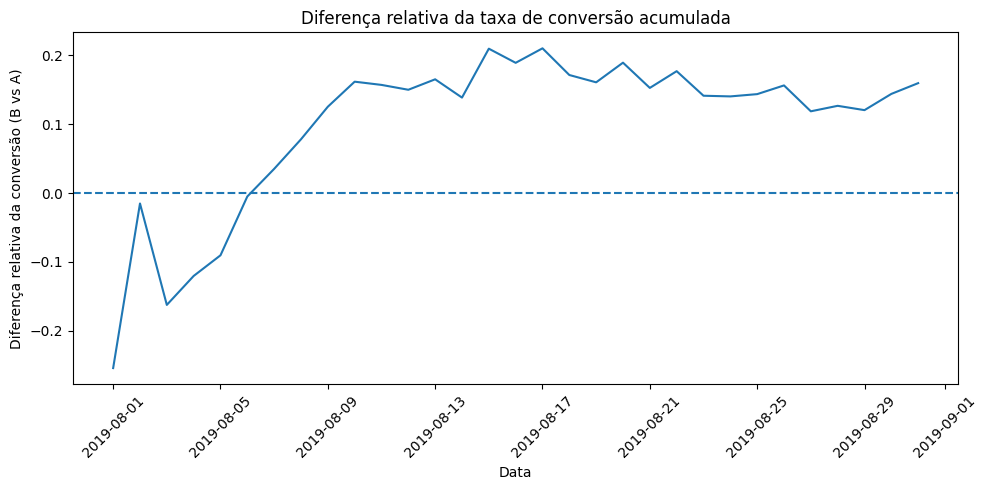

In [39]:
plt.figure(figsize=(10, 5))

plt.plot(
    conversion_pivot.index,
    conversion_pivot['relative_diff']
)

plt.axhline(y=0, linestyle='--')

plt.xlabel('Data')
plt.ylabel('Diferença relativa da conversão (B vs A)')
plt.title('Diferença relativa da taxa de conversão acumulada')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Análise da diferença relativa da taxa de conversão acumulada

O gráfico da diferença relativa da taxa de conversão acumulada mostra como a conversão do grupo B se comporta em relação ao grupo A ao longo do tempo.

No início do experimento, a diferença relativa é negativa, indicando que o grupo A apresentava uma conversão ligeiramente maior. Esse comportamento é esperado nos primeiros dias, quando o volume de dados ainda é baixo.

A partir de aproximadamente uma semana de experimento, a diferença relativa cruza a linha zero e passa a se manter positiva, indicando que o grupo B começa a converter melhor que o grupo A.

Durante a maior parte do período analisado, a diferença relativa permanece positiva, embora com algumas oscilações, e se estabiliza em um nível superior a zero ao final do experimento. Isso sugere um desempenho consistentemente melhor do grupo B em termos de taxa de conversão.


### IDENTIFICAÇÃO DE ANOMALIAS (OUTLIERS)

In [40]:
# Número de pedidos por usuário
orders_by_user = (
    orders_clean
    .groupby('visitorId')['transactionId']
    .nunique()
)

orders_by_user.head()


visitorId
5114589     1
6958315     1
11685486    1
39475350    1
47206413    1
Name: transactionId, dtype: int64

In [41]:
# Calculando percentis
np.percentile(orders_by_user, [95, 99])


array([1., 2.])

### Identificação de anomalias no número de pedidos por usuário

Para identificar usuários anômalos, foi analisada a distribuição do número de pedidos por usuário.

Os percentis calculados indicam que:
- 95% dos usuários realizaram até 1 pedido;
- 99% dos usuários realizaram até 2 pedidos.

Com base nesses valores, usuários que realizaram **mais de 2 pedidos** podem ser considerados anômalos, pois representam um comportamento raro que pode distorcer os resultados do teste A/B.


In [42]:
# Usuários com mais de 2 pedidos
users_with_many_orders = orders_by_user[orders_by_user > 2].index

len(users_with_many_orders)


7

### Gráfico de dispersão 

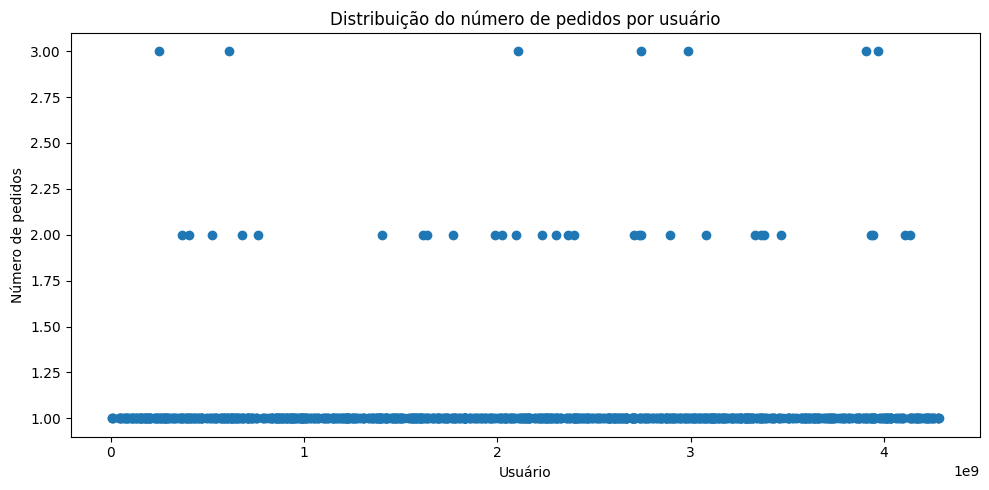

In [43]:
plt.figure(figsize=(10, 5))

plt.scatter(
    orders_by_user.index,
    orders_by_user
)

plt.xlabel('Usuário')
plt.ylabel('Número de pedidos')
plt.title('Distribuição do número de pedidos por usuário')
plt.tight_layout()
plt.show()


### Identificação de usuários anômalos pelo número de pedidos

A análise da distribuição do número de pedidos por usuário mostra que a maioria dos usuários realizou apenas um pedido, enquanto uma parcela menor realizou dois pedidos.

De acordo com os percentis calculados anteriormente, o percentil 95 corresponde a aproximadamente dois pedidos por usuário, e o percentil 99 a três pedidos.

Usuários com três pedidos são raros e aparecem isolados no gráfico de dispersão, indicando comportamento atípico.

Com base nisso, usuários que realizaram **mais de dois pedidos** foram considerados anômalos e serão removidos nas análises filtradas subsequentes.


### ANOMALIAS NO VALOR DOS PEDIDOS

### Gráfico de dispersão no valor dos pedidos

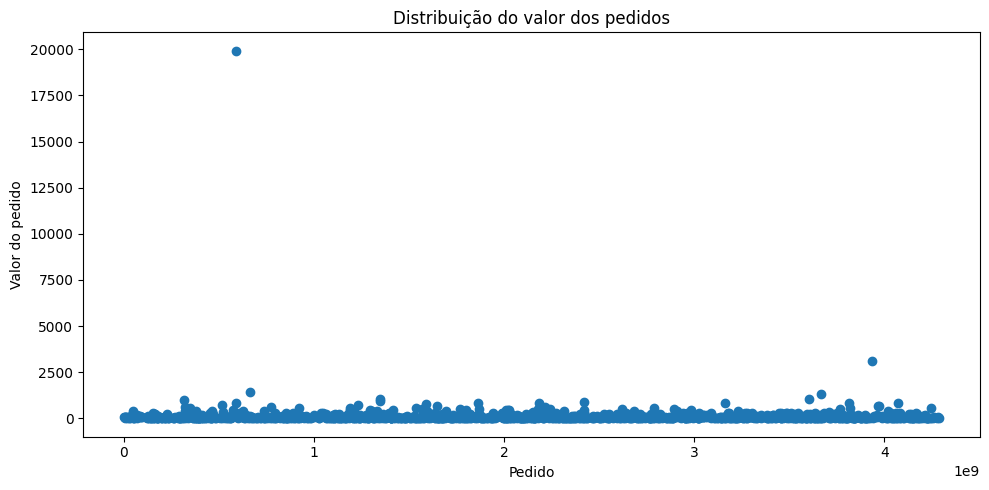

In [44]:
plt.figure(figsize=(10, 5))

plt.scatter(
    orders_clean['transactionId'],
    orders_clean['revenue']
)

plt.xlabel('Pedido')
plt.ylabel('Valor do pedido')
plt.title('Distribuição do valor dos pedidos')
plt.tight_layout()
plt.show()


In [45]:
np.percentile(orders_clean['revenue'], [95, 99])


array([414.275, 830.3  ])

### Identificação de pedidos anômalos pelo valor

A análise da distribuição dos valores dos pedidos mostra que a maioria das compras possui valores relativamente baixos, enquanto poucos pedidos apresentam valores muito elevados.

De acordo com os percentis calculados, aproximadamente 95% dos pedidos possuem valor até cerca de 414, enquanto 99% possuem valor até cerca de 830.

Pedidos acima desse valor são raros e aparecem isolados no gráfico de dispersão, caracterizando comportamento atípico.

Com base nisso, pedidos com valor **superior a 830** foram considerados anômalos e serão removidos nas análises filtradas subsequentes.


### TESTE 1 — CONVERSÃO (DADOS BRUTOS)

In [46]:
# Pedidos totais por grupo (dados brutos)
orders_by_group = (
    orders_clean
    .groupby('group')['transactionId']
    .nunique()
)

# Visitas totais por grupo
visits_by_group = (
    visits
    .groupby('group')['visits']
    .sum()
)

orders_by_group, visits_by_group


(group
 A    468
 B    548
 Name: transactionId, dtype: int64,
 group
 A    18736
 B    18916
 Name: visits, dtype: int64)

In [47]:
orders_by_group, visits_by_group


(group
 A    468
 B    548
 Name: transactionId, dtype: int64,
 group
 A    18736
 B    18916
 Name: visits, dtype: int64)

### TESTE Z PARA CONVERSÃO 

In [48]:
orders_counts = [
    orders_by_group['A'],
    orders_by_group['B']
]

visits_counts = [
    visits_by_group['A'],
    visits_by_group['B']
]

z_stat, p_value = proportions_ztest(
    orders_counts,
    visits_counts
)

z_stat, p_value


(-2.3899344431697442, 0.01685138043470311)

In [ ]:
# ordersByUsersA = orders[orders['group']=='A'].groupby('visitorId', as_index=False).agg({'transactionId' : pd.Series.nunique})
# ordersByUsersA.columns = ['visitorId', 'orders']

# ordersByUsersB = orders[orders['group']=='B'].groupby('visitorId', as_index=False).agg({'transactionId' : pd.Series.nunique})
# ordersByUsersB.columns = ['visitorId', 'orders']

# sampleA = pd.concat([ordersByUsersA['orders'],pd.Series(0, index=np.arange(visitors[visitors['group']=='A']['visitors'].sum() - len(ordersByUsersA['orders'])), name='orders')],axis=0)
# sampleB = pd.concat([ordersByUsersB['orders'],pd.Series(0, index=np.arange(visitors[visitors['group']=='B']['visitors'].sum() - len(ordersByUsersB['orders'])), name='orders')],axis=0)

# print("{0:.5f}".format(stats.mannwhitneyu(sampleA, sampleB)[1]))
# print("{0:.3f}".format(sampleB.mean()/sampleA.mean()-1))


### Teste de significância estatística da conversão (dados brutos)

Para verificar se a diferença observada nas taxas de conversão entre os grupos A e B é estatisticamente significativa, foi aplicado um teste z para proporções.

As hipóteses do teste são:
- **H₀ (hipótese nula)**: as taxas de conversão dos grupos A e B são iguais.
- **H₁ (hipótese alternativa)**: as taxas de conversão dos grupos A e B são diferentes.

O teste resultou em um valor-p de aproximadamente **0,017**, que é menor que o nível de significância de **0,05**.

Dessa forma, rejeitamos a hipótese nula e concluímos que existe uma **diferença estatisticamente significativa** entre as taxas de conversão dos grupos. Os resultados indicam que o **grupo B apresenta uma taxa de conversão maior** que o grupo A.


### TESTE 2 — AOV (DADOS BRUTOS)

In [49]:
# Valores dos pedidos por grupo (dados brutos)
revenue_A = orders_clean[orders_clean['group'] == 'A']['revenue']
revenue_B = orders_clean[orders_clean['group'] == 'B']['revenue']

revenue_A.head(), revenue_B.head()


(7      20.1
 8     215.9
 10     65.7
 12    115.4
 14    170.9
 Name: revenue, dtype: float64,
 0     30.4
 1     15.2
 3    155.1
 4     40.5
 5     35.0
 Name: revenue, dtype: float64)

In [50]:
u_stat, p_value_aov = stats.mannwhitneyu(
    revenue_A,
    revenue_B,
    alternative='two-sided'
)

u_stat, p_value_aov


(129041.5, 0.8622329690015668)

### Teste de significância estatística do tamanho médio do pedido (dados brutos)

Para avaliar se existe uma diferença estatisticamente significativa no tamanho médio dos pedidos entre os grupos A e B, foi aplicado o teste não paramétrico de Mann-Whitney U.

As hipóteses do teste são:
- **H₀ (hipótese nula)**: os tamanhos médios dos pedidos dos grupos A e B são iguais.
- **H₁ (hipótese alternativa)**: os tamanhos médios dos pedidos dos grupos A e B são diferentes.

O teste resultou em um valor-p de aproximadamente **0,86**, que é significativamente maior que o nível de significância de **0,05**.

Dessa forma, não rejeitamos a hipótese nula e concluímos que **não há diferença estatisticamente significativa** entre os tamanhos médios dos pedidos dos grupos quando utilizamos os dados brutos.


### TESTES COM DADOS FILTRADOS (SEM ANOMALIAS)

In [52]:
# Definindo limites de anomalias
max_orders_per_user = 2
max_revenue = 830


In [53]:
# Usuários com muitos pedidos
users_with_many_orders = (
    orders_clean
    .groupby('visitorId')['transactionId']
    .nunique()
    .reset_index()
)

users_with_many_orders = users_with_many_orders[
    users_with_many_orders['transactionId'] > max_orders_per_user
]['visitorId']

users_with_many_orders.head()


55      249864742
138     611059232
478    2108163459
632    2742574263
687    2988190573
Name: visitorId, dtype: int64

In [54]:
# Pedidos com valor muito alto
orders_with_high_revenue = orders_clean[
    orders_clean['revenue'] > max_revenue
]['transactionId']

orders_with_high_revenue.head()


131    3163614039
287     587872075
425     590470918
613    4071177889
743    3603576309
Name: transactionId, dtype: int64

In [55]:
# Removendo anomalias
orders_filtered = orders_clean[
    ~orders_clean['visitorId'].isin(users_with_many_orders) &
    ~orders_clean['transactionId'].isin(orders_with_high_revenue)
]

orders_filtered.head()


,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B
5,182168103,935554773,2019-08-15,35.0,B


### TESTE 3 — CONVERSÃO (DADOS FILTRADOS)

In [56]:
# Pedidos filtrados por grupo
orders_filtered_by_group = (
    orders_filtered
    .groupby('group')['transactionId']
    .nunique()
)

# Visitas totais por grupo (mesmas de antes)
visits_by_group = (
    visits
    .groupby('group')['visits']
    .sum()
)

orders_filtered_by_group, visits_by_group


(group
 A    446
 B    537
 Name: transactionId, dtype: int64,
 group
 A    18736
 B    18916
 Name: visits, dtype: int64)

In [57]:
orders_counts_filtered = [
    orders_filtered_by_group['A'],
    orders_filtered_by_group['B']
]

visits_counts = [
    visits_by_group['A'],
    visits_by_group['B']
]

z_stat_filtered, p_value_filtered = proportions_ztest(
    orders_counts_filtered,
    visits_counts
)

z_stat_filtered, p_value_filtered


(-2.78924557365156, 0.00528309886249398)

### Teste de significância estatística da conversão (dados filtrados)

Após a remoção de usuários anômalos e pedidos de valor atípico, foi aplicado novamente o teste z para proporções a fim de comparar as taxas de conversão dos grupos A e B.

O teste resultou em um valor-p de aproximadamente **0,005**, que é menor que o nível de significância de **0,05**.

Dessa forma, rejeitamos a hipótese nula e concluímos que a diferença observada nas taxas de conversão entre os grupos é **estatisticamente significativa mesmo após a filtragem dos dados**. Os resultados indicam que o **grupo B mantém uma taxa de conversão superior** ao grupo A.


### TESTE 4 — AOV (DADOS FILTRADOS)

In [58]:
# Valores dos pedidos por grupo (dados filtrados)
revenue_A_filtered = orders_filtered[orders_filtered['group'] == 'A']['revenue']
revenue_B_filtered = orders_filtered[orders_filtered['group'] == 'B']['revenue']

revenue_A_filtered.head(), revenue_B_filtered.head()


(7      20.1
 8     215.9
 10     65.7
 12    115.4
 14    170.9
 Name: revenue, dtype: float64,
 0     30.4
 1     15.2
 3    155.1
 4     40.5
 5     35.0
 Name: revenue, dtype: float64)

In [59]:
u_stat_filt, p_value_aov_filt = stats.mannwhitneyu(
    revenue_A_filtered,
    revenue_B_filtered,
    alternative='two-sided'
)

u_stat_filt, p_value_aov_filt


(120439.0, 0.8767101122551697)

### Teste de significância estatística do tamanho médio do pedido (dados filtrados)

Após a remoção de usuários anômalos e pedidos de valor atípico, foi aplicado novamente o teste de Mann-Whitney U para comparar os tamanhos médios dos pedidos entre os grupos A e B.

O teste resultou em um valor-p de aproximadamente **0,88**, que é maior que o nível de significância de **0,05**.

Dessa forma, não rejeitamos a hipótese nula e concluímos que **não há diferença estatisticamente significativa** no tamanho médio dos pedidos entre os grupos A e B, mesmo após a filtragem dos dados.


### Decisão final do teste A/B

Com base nos resultados da análise visual e dos testes estatísticos, foi possível observar que o **grupo B apresenta uma taxa de conversão significativamente maior** do que o grupo A, tanto nos dados brutos quanto nos dados filtrados.

Por outro lado, não foram identificadas diferenças estatisticamente significativas no tamanho médio dos pedidos entre os grupos, indicando que o aumento de receita do grupo B está relacionado principalmente à maior conversão.

Como a diferença na conversão é consistente e estatisticamente significativa, a decisão é **encerrar o teste e considerar o grupo B como líder**.
